#### Manually for each cell type, inspect possible doublets or outlier cells. Save this in the output directory

The leiden clusters don't always correspond one to one with cell types, and sometimes we see possible doublets that were not removed by scrublet but show expression of marker genes for two different cell types. We will do this extra manual inspection step to try to ensure that the cells are annotated correctly and are not doublets. Additionally, some cells are not in the same region of the UMAP plot. While UMAP has some limitations, these could reflect cells that are truly not belonging to the same cell type as the other cell types in their leiden cluster. Therefore, we will use marker gene expression.

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
def add_umap_coords(adata):
    '''Add UMAP1 and UMAP2 to the obs DataFrame for easier manipulation, as scanpy does not show coordinates'''
    umap_coords = adata.obsm["X_umap"]
    adata.obs["UMAP1"] = umap_coords[:, 0]
    adata.obs["UMAP2"] = umap_coords[:, 1]
    return(adata)

In [3]:
# input dir where the subsetted cell type adatas are located 
input_dir = "scvi_pre_cleanup_subset_cell_type_adata/"

# output dir to store the updated adata
output_dir = "scvi_post_subclustering/"

In [4]:
os.makedirs(output_dir, exist_ok = True)

In [5]:
leiden_key = "redo_leiden_0.5"

### Adipocyte

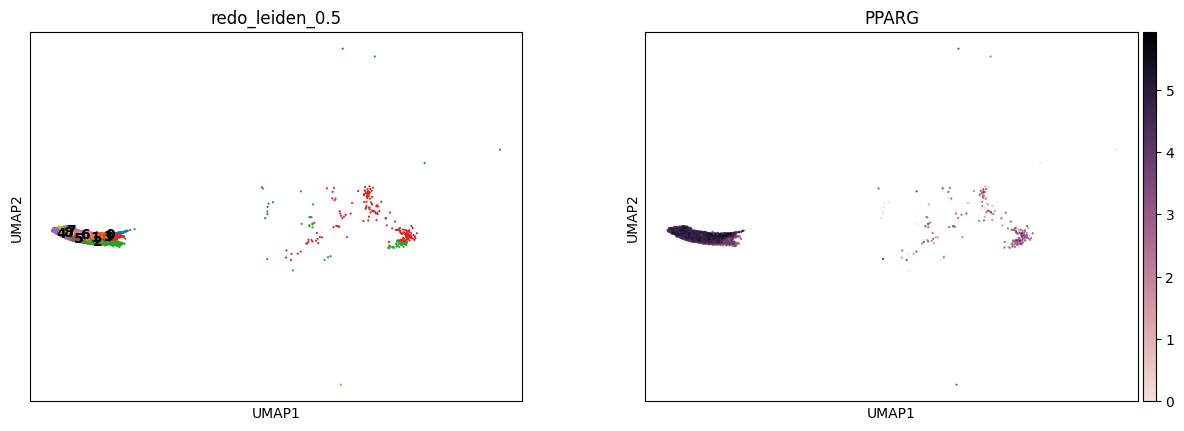

CPU times: user 704 ms, sys: 1.41 s, total: 2.11 s
Wall time: 4.6 s


In [6]:
%%time
Adipocyte_adata = sc.read_h5ad(input_dir + "Adipocyte.h5ad")
Adipocyte_markers = ["PPARG"]
sc.pl.umap(Adipocyte_adata, color=[leiden_key] + Adipocyte_markers, legend_loc = "on data", ncols = 2,
          cmap=sns.cubehelix_palette(dark=0, light=.9, as_cmap=True))

In [7]:
#sc.pl.rank_genes_groups_dotplot(Adipocyte_adata, groupby=leiden_key, standard_scale="var", n_genes = 3)

<Axes: xlabel='UMAP1', ylabel='UMAP2'>

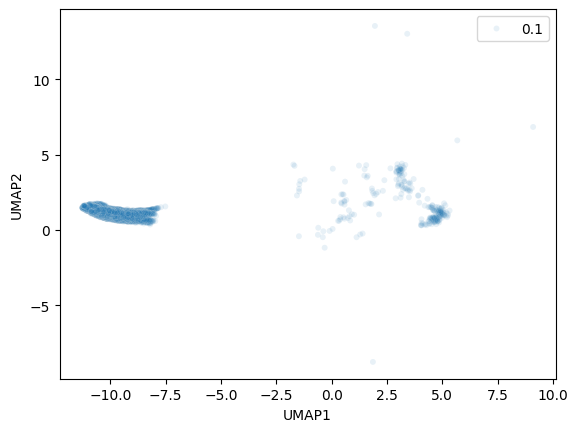

In [8]:
Adipocyte_adata = add_umap_coords(Adipocyte_adata)
sns.scatterplot(data = Adipocyte_adata.obs, x = 'UMAP1', y = 'UMAP2', size = 0.1, alpha = 0.1)

Number of cells filtered out: 268


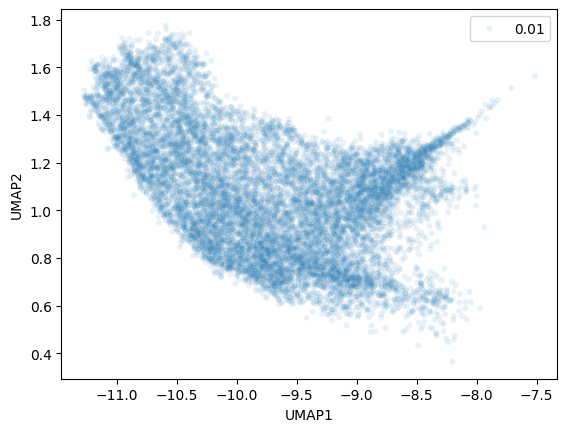

In [10]:
filtered_Adipocyte_adata = ( Adipocyte_adata[(Adipocyte_adata.obs.UMAP1 < -5) , :] )
sns.scatterplot(data = filtered_Adipocyte_adata.obs, x = 'UMAP1', y = 'UMAP2', size = 0.01, alpha = 0.1)
print(f"Number of cells filtered out: {Adipocyte_adata.shape[0] - filtered_Adipocyte_adata.shape[0]}")

In [11]:
%%time
filtered_Adipocyte_adata.obs['v2_scvi_cell_type'] = "Adipocyte"
filtered_Adipocyte_adata.write(output_dir + "Adipocyte_filtered.h5ad")

<timed exec>:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


CPU times: user 719 ms, sys: 8.09 s, total: 8.81 s
Wall time: 8.88 s


### Cardiomyocyte

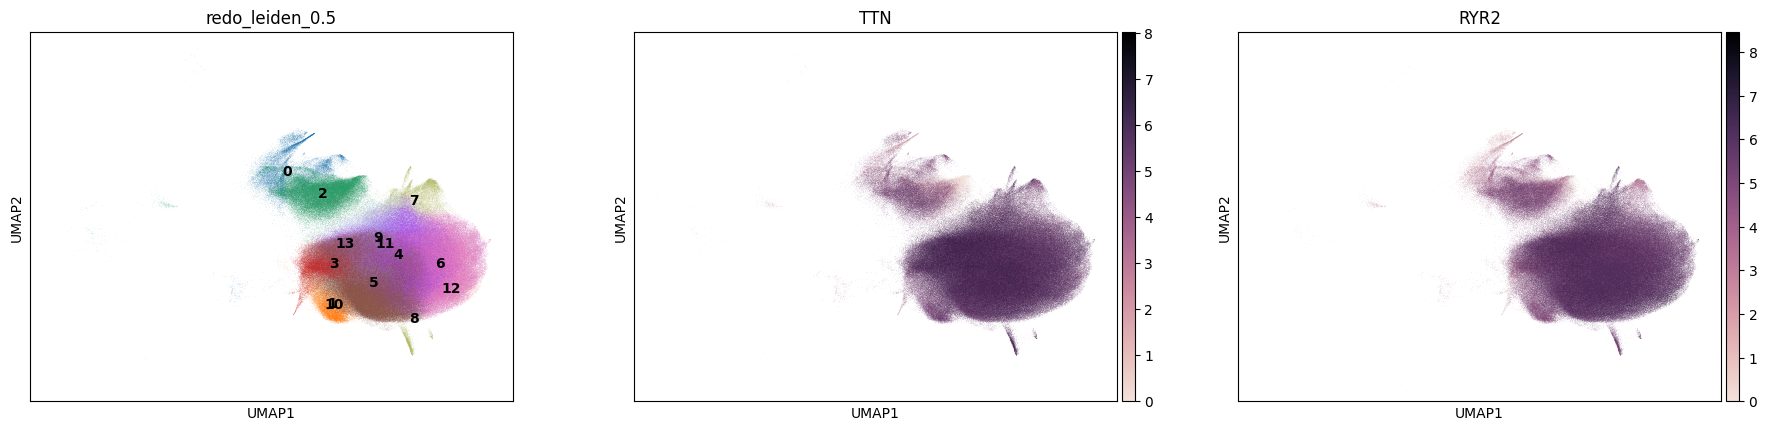

CPU times: user 18.1 s, sys: 57.4 s, total: 1min 15s
Wall time: 2min 45s


In [14]:
%%time
CM_adata = sc.read_h5ad(input_dir + "Cardiomyocyte.h5ad")
CM_markers = ["TTN", "RYR2"]
sc.pl.umap(CM_adata, color=[leiden_key] + CM_markers, legend_loc = "on data",
          cmap=sns.cubehelix_palette(dark=0, light=.9, as_cmap=True))

In [25]:
sc.get.rank_genes_groups_df(CM_adata, group = "0").head(10)

,names,scores,logfoldchanges,pvals,pvals_adj
0,MYL4,209.865814,5.941536,0.0,0.0
1,TNNI1,185.797775,6.649242,0.0,0.0
2,EEF1A1,177.526230,5.245965,0.0,0.0
3,RPL37A,171.077408,4.506739,0.0,0.0
4,MYL7,168.330338,5.024255,0.0,0.0
5,RPLP1,164.042709,4.147590,0.0,0.0
6,NPPA,162.988815,5.378658,0.0,0.0
7,RPS16,158.917587,4.378315,0.0,0.0
8,ACTC1,158.237930,2.678154,0.0,0.0
9,RPL23,156.520294,4.876152,0.0,0.0


#### The cluster may correspond to atrial cardiomyocytes, so remove from this analysis

<Axes: xlabel='UMAP1', ylabel='UMAP2'>

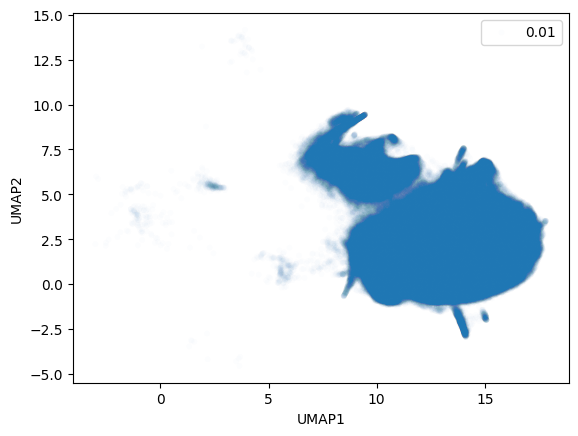

In [15]:
# Add UMAP1 and UMAP2 to the obs DataFrame
CM_adata = add_umap_coords(CM_adata)
sns.scatterplot(data = CM_adata.obs, x = 'UMAP1', y = 'UMAP2', size = 0.01, alpha = 0.01)

Number of cells filtered out: 99893
CPU times: user 1.56 s, sys: 83.8 ms, total: 1.64 s
Wall time: 1.62 s


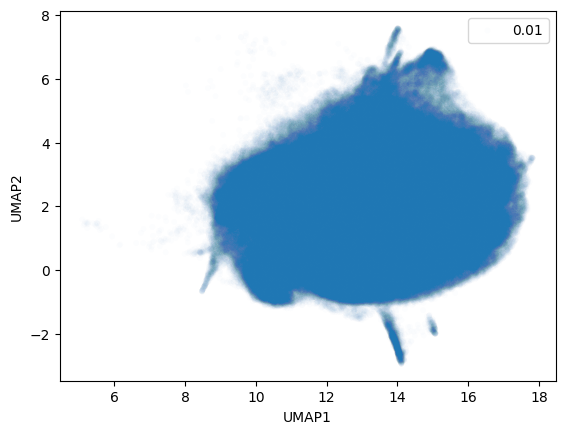

In [26]:
%%time
filtered_CM_adata = CM_adata[~CM_adata.obs[leiden_key].isin(["0", "2"])]
filtered_CM_adata = ( filtered_CM_adata[(filtered_CM_adata.obs.UMAP1 > 5) & 
                     (filtered_CM_adata.obs.UMAP2 < 13) & (filtered_CM_adata.obs.UMAP2 > -3), :] )
sns.scatterplot(data = filtered_CM_adata.obs, x = 'UMAP1', y = 'UMAP2', size = 0.01, alpha = 0.01)
print(f"Number of cells filtered out: {CM_adata.shape[0] - filtered_CM_adata.shape[0]}")

In [27]:
%%time
filtered_CM_adata.obs['v2_scvi_cell_type'] = "Cardiomyocyte"
filtered_CM_adata.write(output_dir + "Cardiomyocyte_filtered.h5ad")

<timed exec>:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


CPU times: user 41.5 s, sys: 2min 46s, total: 3min 28s
Wall time: 3min 32s


### Endocardial

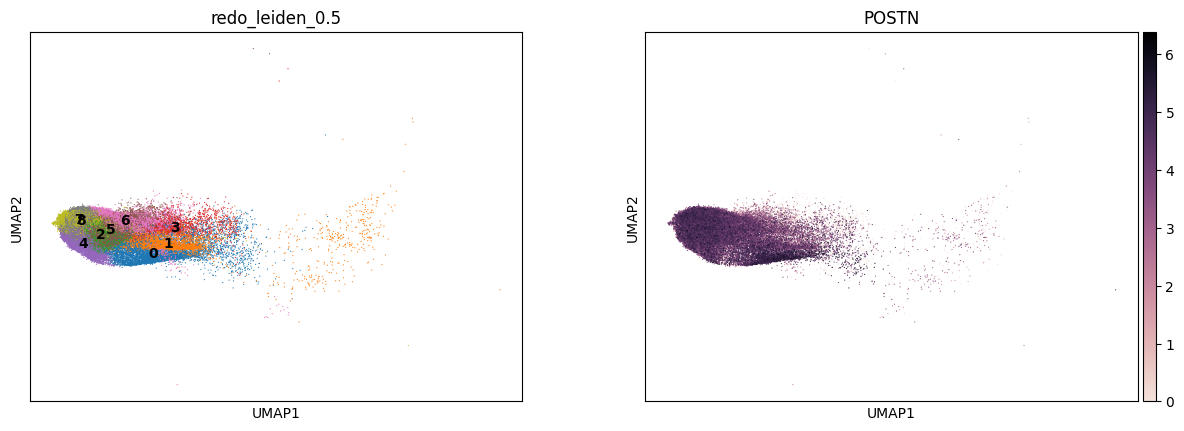

CPU times: user 917 ms, sys: 2.47 s, total: 3.38 s
Wall time: 4.46 s


In [28]:
%%time
Endocardial_adata = sc.read_h5ad(input_dir + "Endocardial.h5ad")
Endocardial_markers = ["POSTN"]
sc.pl.umap(Endocardial_adata, color=[leiden_key] + Endocardial_markers, legend_loc = "on data",
          cmap=sns.cubehelix_palette(dark=0, light=.9, as_cmap=True))

<Axes: xlabel='UMAP1', ylabel='UMAP2'>

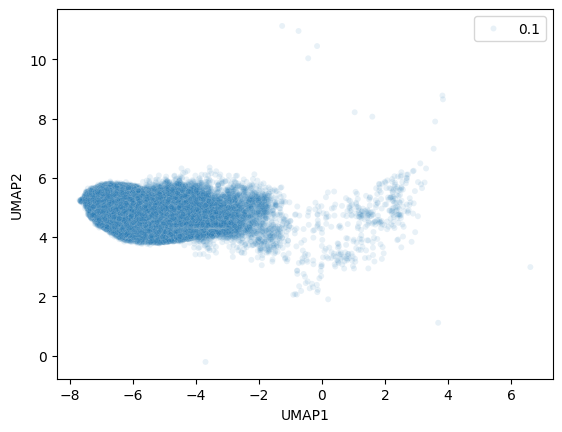

In [29]:
Endocardial_adata = add_umap_coords(Endocardial_adata)
sns.scatterplot(data = Endocardial_adata.obs, x = 'UMAP1', y = 'UMAP2', size = 0.1, alpha = 0.1)

Number of cells filtered out: 399


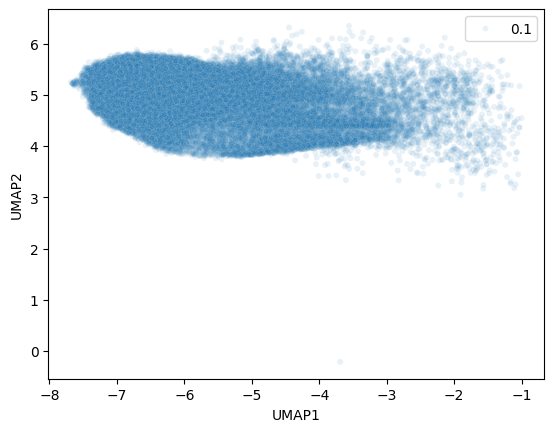

In [40]:
filtered_Endocardial_adata = (Endocardial_adata[(Endocardial_adata.obs.UMAP1 < -1) & (Endocardial_adata.obs.UMAP2 < 8), :] )
sns.scatterplot(data = filtered_Endocardial_adata.obs, x = 'UMAP1', y = 'UMAP2', size = 0.1, alpha = 0.1)
print(f"Number of cells filtered out: {Endocardial_adata.shape[0] - filtered_Endocardial_adata.shape[0]}")

In [41]:
%%time
filtered_Endocardial_adata.obs['v2_scvi_cell_type'] = "Endocardial"
filtered_Endocardial_adata.write(output_dir + "Endocardial_filtered.h5ad")

<timed exec>:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


CPU times: user 1.62 s, sys: 2.78 s, total: 4.4 s
Wall time: 4.54 s


### Endothelial

In [30]:
%%time
Endothelial_adata = sc.read_h5ad(input_dir + "Endothelial.h5ad")

CPU times: user 1.74 s, sys: 7.46 s, total: 9.21 s
Wall time: 9.21 s


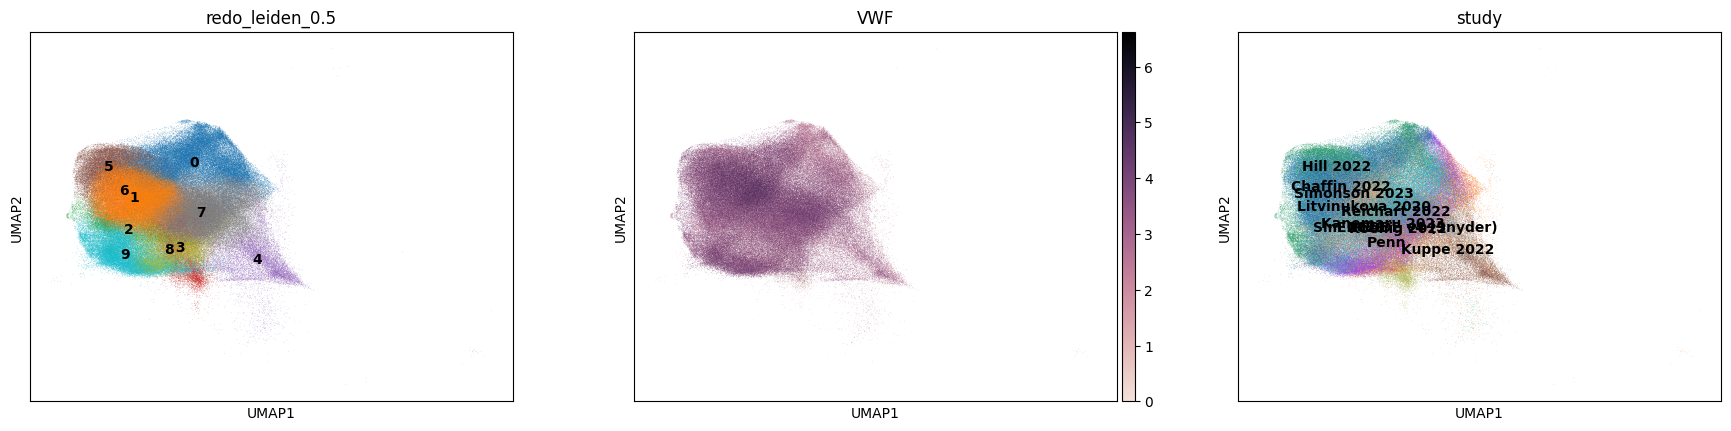

In [42]:
Endothelial_markers = ["VWF", "study"]
sc.pl.umap(Endothelial_adata, color=[leiden_key] + Endothelial_markers, legend_loc = "on data",
          cmap=sns.cubehelix_palette(dark=0, light=.9, as_cmap=True))

<Axes: xlabel='UMAP1', ylabel='UMAP2'>

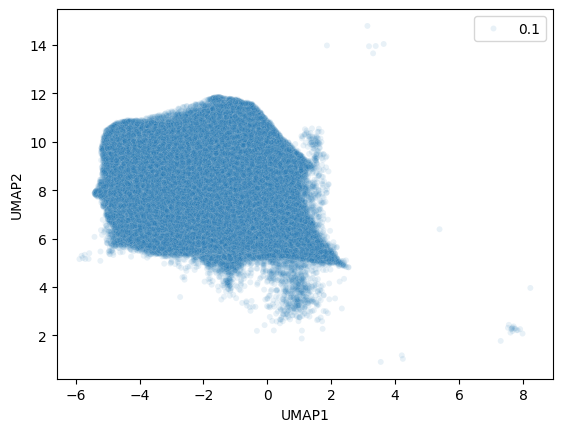

In [43]:
Endothelial_adata = add_umap_coords(Endothelial_adata)
sns.scatterplot(data = Endothelial_adata.obs, x = 'UMAP1', y = 'UMAP2', size = 0.1, alpha = 0.1)

Number of cells filtered out: 592


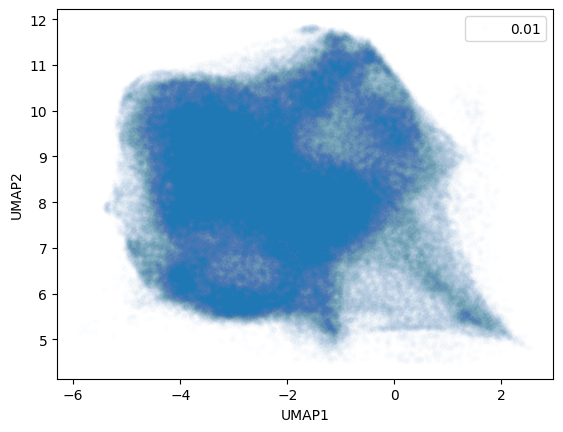

In [44]:
filtered_Endothelial_adata = ( Endothelial_adata[(Endothelial_adata.obs.UMAP1 < 3) & 
                              (Endothelial_adata.obs.UMAP2 < 13) & (Endothelial_adata.obs.UMAP2 > 4.5), :] )
sns.scatterplot(data = filtered_Endothelial_adata.obs, x = 'UMAP1', y = 'UMAP2', size = 0.01, alpha = 0.01)
print(f"Number of cells filtered out: {Endothelial_adata.shape[0] - filtered_Endothelial_adata.shape[0]}")

In [46]:
%%time
filtered_Endothelial_adata.obs['v2_scvi_cell_type'] = "Endothelial"
filtered_Endothelial_adata.write(output_dir + "Endothelial_filtered.h5ad")

<timed exec>:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


CPU times: user 8.22 s, sys: 21.3 s, total: 29.5 s
Wall time: 30.8 s


### Epicardial

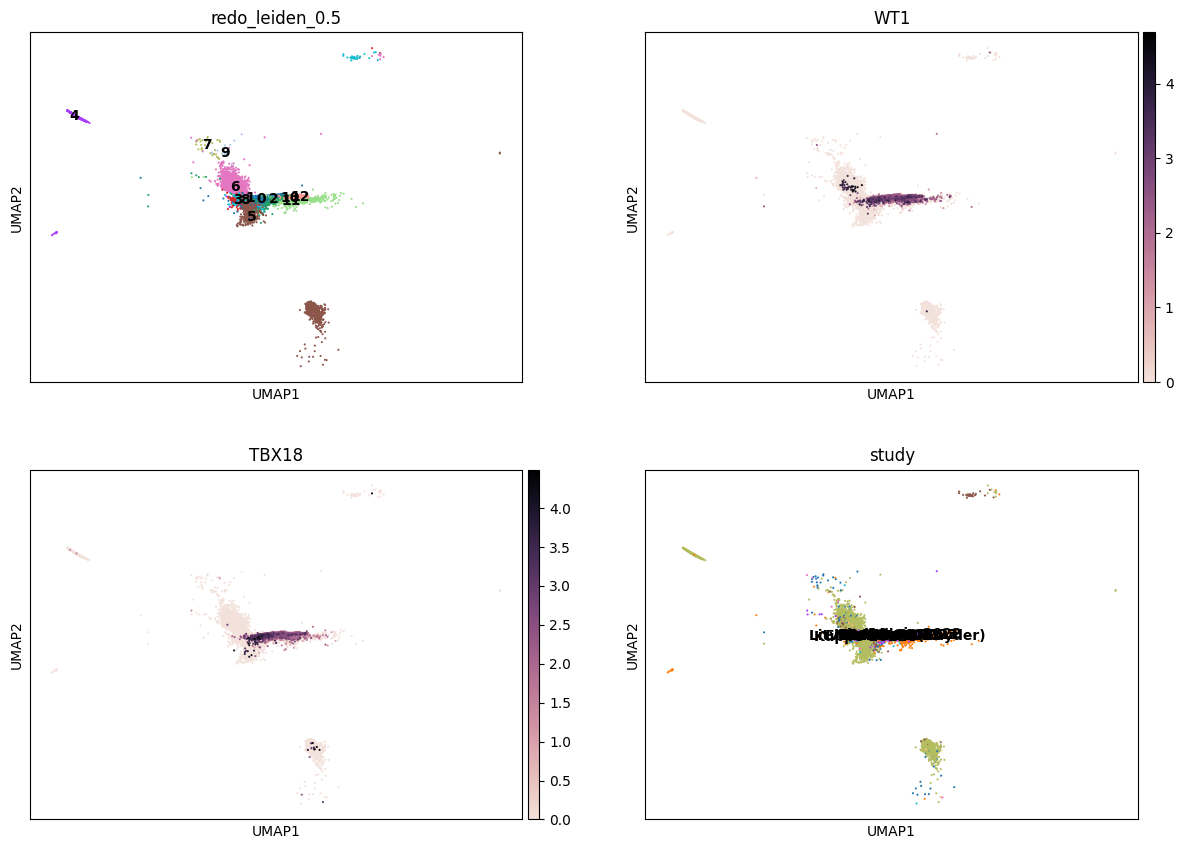

In [12]:
Epicardial_adata = sc.read_h5ad(input_dir + "Epicardial.h5ad")
Epicardial_markers = ["WT1", "TBX18", "study"]
sc.pl.umap(Epicardial_adata, color=[leiden_key] + Epicardial_markers, legend_loc = "on data", 
           cmap=sns.cubehelix_palette(dark=0, light=.9, as_cmap=True), ncols = 2)

<Axes: xlabel='UMAP1', ylabel='UMAP2'>

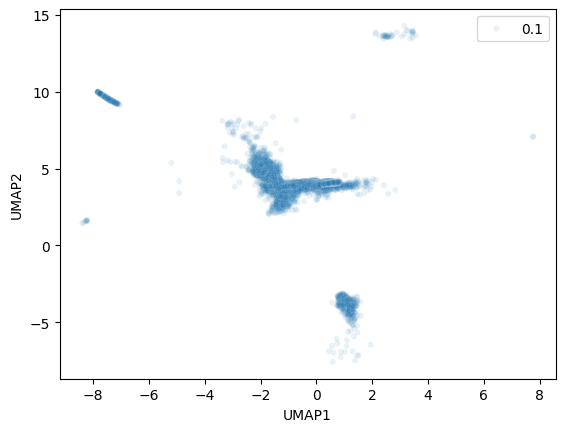

In [13]:
Epicardial_adata = add_umap_coords(Epicardial_adata)
sns.scatterplot(data = Epicardial_adata.obs, x = 'UMAP1', y = 'UMAP2', size = 0.1, alpha = 0.1)

Number of cells filtered out: 1266


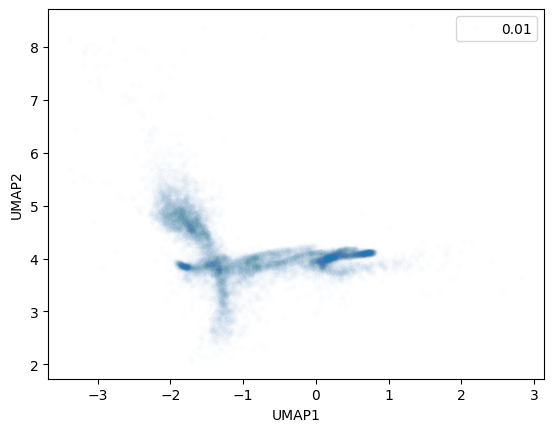

In [14]:
filtered_Epicardial_adata = ( Epicardial_adata[(Epicardial_adata.obs.UMAP1 < 3) & (Epicardial_adata.obs.UMAP1 > -4) &
                              (Epicardial_adata.obs.UMAP2 < 10) & (Epicardial_adata.obs.UMAP2 > 0), :] )
sns.scatterplot(data = filtered_Epicardial_adata.obs, x = 'UMAP1', y = 'UMAP2', size = 0.01, alpha = 0.01)
print(f"Number of cells filtered out: {Epicardial_adata.shape[0] - filtered_Epicardial_adata.shape[0]}")

In [16]:
%%time
filtered_Epicardial_adata.obs['v2_scvi_cell_type'] = "Epicardial"
filtered_Epicardial_adata.write(output_dir + "Epicardial_filtered.h5ad")

CPU times: user 329 ms, sys: 419 ms, total: 748 ms
Wall time: 749 ms


### Fibroblast

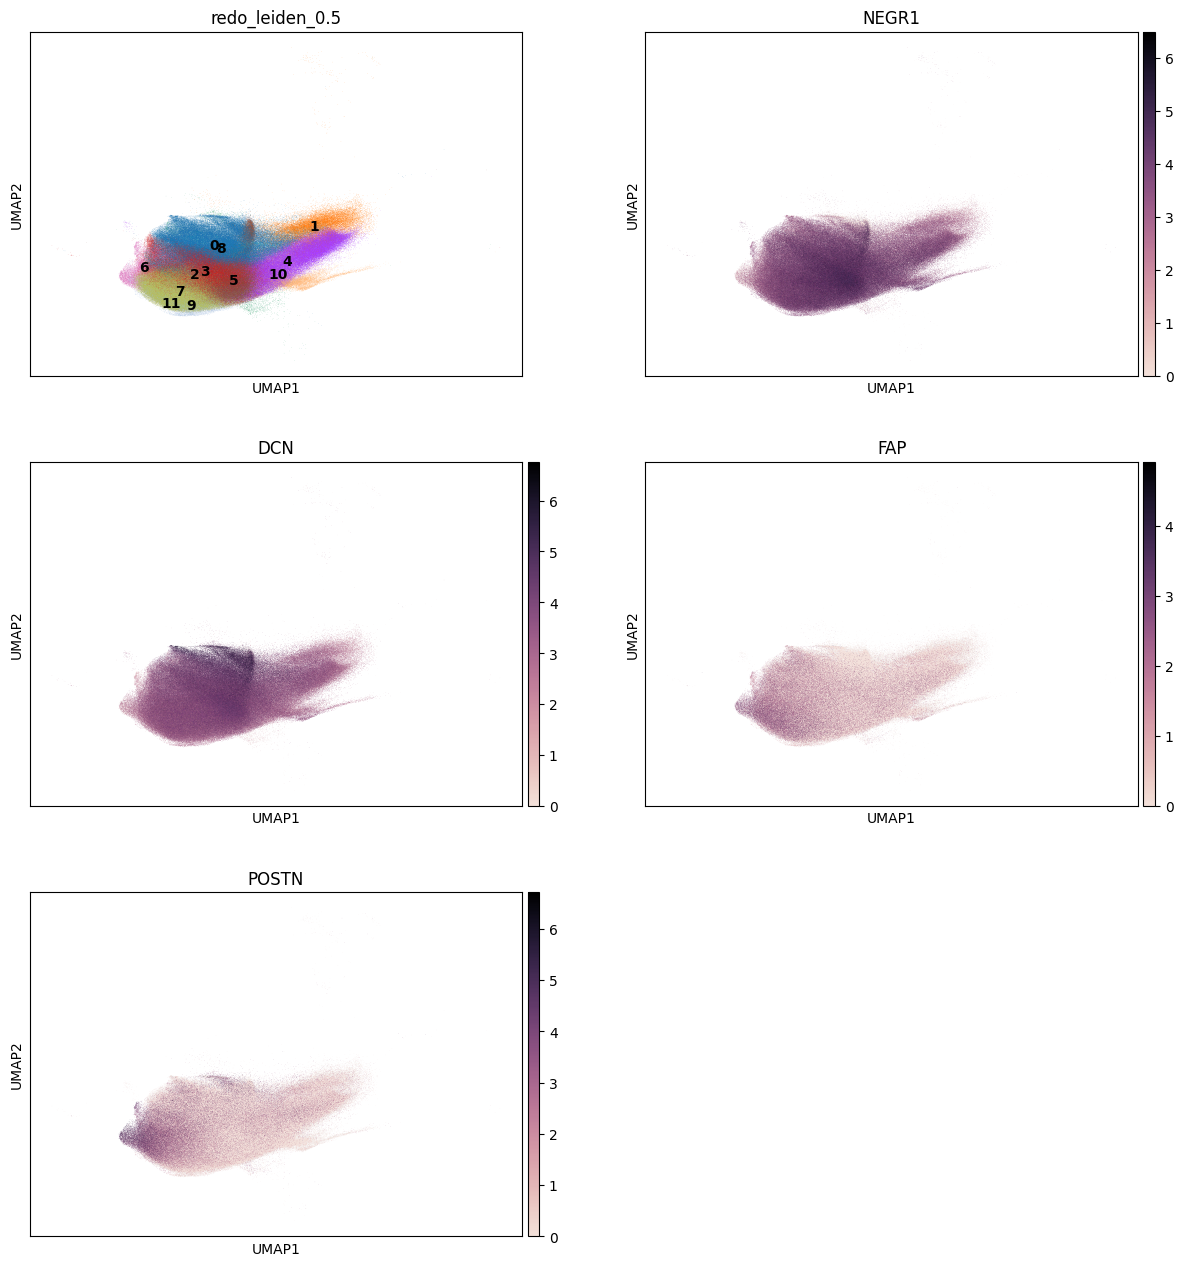

CPU times: user 16.6 s, sys: 32.9 s, total: 49.5 s
Wall time: 2min 46s


In [32]:
%%time
Fibroblast_adata = sc.read_h5ad(input_dir + "Fibroblast.h5ad")
Fibroblast_markers = ["NEGR1", "DCN", "FAP", "POSTN"]
sc.pl.umap(Fibroblast_adata, color=[leiden_key] + Fibroblast_markers, legend_loc = "on data", 
           cmap=sns.cubehelix_palette(dark=0, light=.9, as_cmap=True), ncols = 2)

<Axes: xlabel='UMAP1', ylabel='UMAP2'>

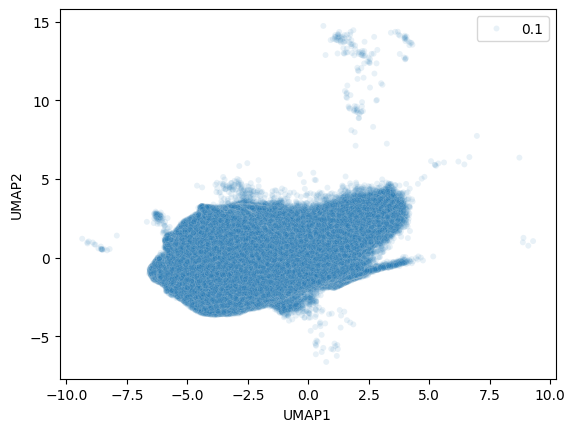

In [54]:
# Add UMAP1 and UMAP2 to the obs DataFrame
Fibroblast_adata = add_umap_coords(Fibroblast_adata)
sns.scatterplot(data = Fibroblast_adata.obs, x = 'UMAP1', y = 'UMAP2', size = 0.1, alpha = 0.1)

Number of cells filtered out: 206


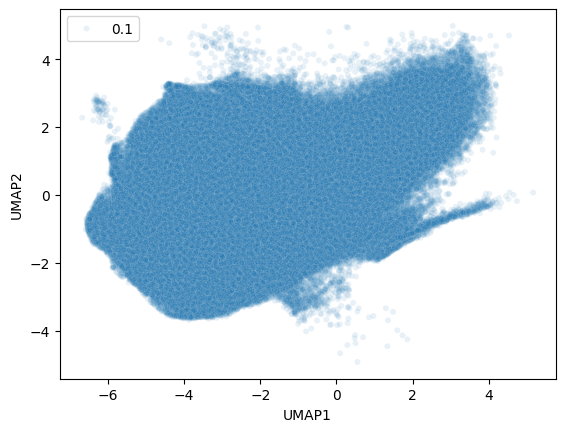

In [56]:
filtered_Fibroblast_adata = ( Fibroblast_adata[(Fibroblast_adata.obs.UMAP2 < 5) & (Fibroblast_adata.obs.UMAP2 > -5) &
                             (Fibroblast_adata.obs.UMAP1 > -7.5) & (Fibroblast_adata.obs.UMAP1 < 5.5), :] )
sns.scatterplot(data = filtered_Fibroblast_adata.obs, x = 'UMAP1', y = 'UMAP2', size = 0.1, alpha = 0.1)
print(f"Number of cells filtered out: {Fibroblast_adata.shape[0] - filtered_Fibroblast_adata.shape[0]}")

In [57]:
%%time
filtered_Fibroblast_adata.obs['v2_scvi_cell_type'] = "Fibroblast"
filtered_Fibroblast_adata.write(output_dir + "Fibroblast_filtered.h5ad")

<timed exec>:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


CPU times: user 19.3 s, sys: 1min 50s, total: 2min 9s
Wall time: 2min 13s


### LEC

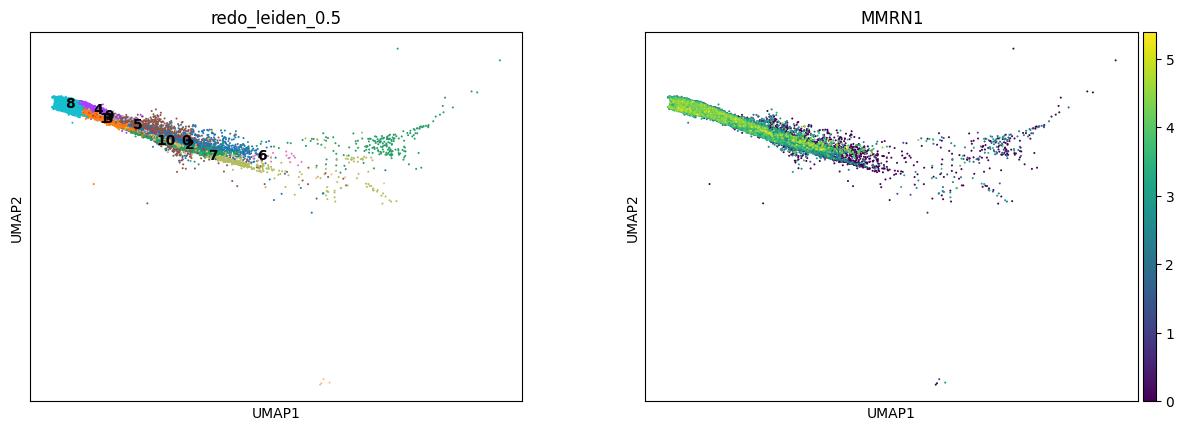

CPU times: user 499 ms, sys: 621 ms, total: 1.12 s
Wall time: 940 ms


In [33]:
%%time
LEC_adata = sc.read_h5ad(input_dir + "LEC.h5ad")
LEC_markers = ["MMRN1"]
sc.pl.umap(LEC_adata, color=[leiden_key] + LEC_markers, legend_loc = "on data")

<Axes: xlabel='UMAP1', ylabel='UMAP2'>

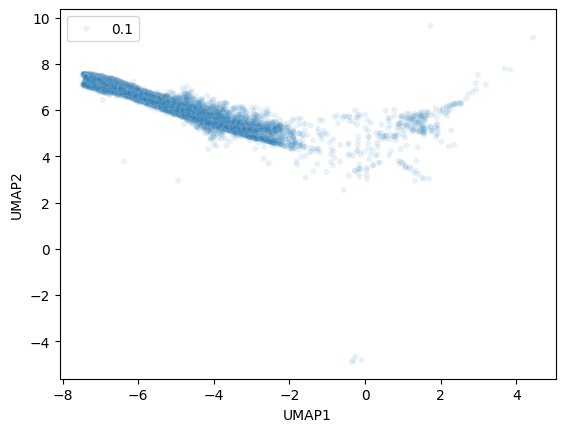

In [58]:
LEC_adata = add_umap_coords(LEC_adata)
sns.scatterplot(data = LEC_adata.obs, x = 'UMAP1', y = 'UMAP2', size = 0.1, alpha = 0.1)

Number of cells filtered out: 234 cells


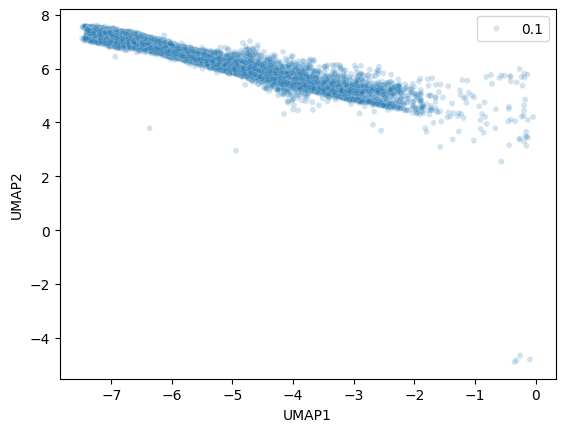

In [59]:
LEC_adata_filtered = ( LEC_adata[(LEC_adata.obs.UMAP1 < 0) , :] )
sns.scatterplot(data = LEC_adata_filtered.obs, x = 'UMAP1', y = 'UMAP2', size = 0.1, alpha = 0.2)
print(f"Number of cells filtered out: {LEC_adata.shape[0] - LEC_adata_filtered.shape[0]} cells")

In [60]:
%%time
LEC_adata_filtered.obs['v2_scvi_cell_type'] = "LEC"
LEC_adata_filtered.write(output_dir + "LEC_filtered.h5ad")

<timed exec>:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


CPU times: user 778 ms, sys: 1.1 s, total: 1.88 s
Wall time: 1.92 s


### Lymphoid

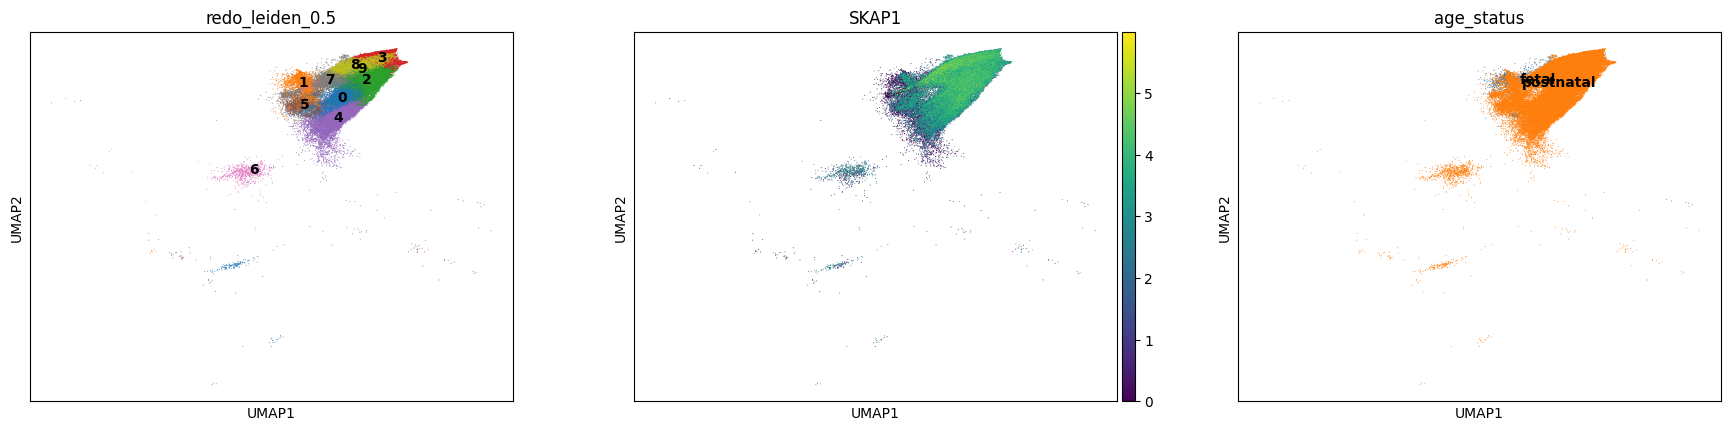

In [6]:
Lymphoid_adata = sc.read_h5ad(input_dir + "Lymphoid.h5ad")
Lymphoid_markers = ["SKAP1", "age_status"]
sc.pl.umap(Lymphoid_adata, color=[leiden_key] + Lymphoid_markers, legend_loc = "on data")

<Axes: xlabel='UMAP1', ylabel='UMAP2'>

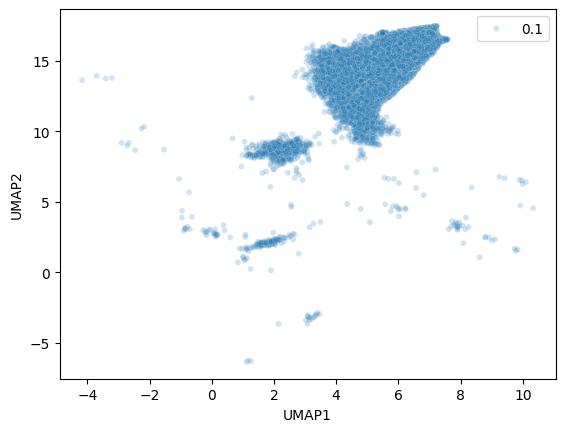

In [7]:
Lymphoid_adata = add_umap_coords(Lymphoid_adata)
sns.scatterplot(data = Lymphoid_adata.obs, x = 'UMAP1', y = 'UMAP2', size = 0.1, alpha = 0.2)

In [9]:
sc.tl.rank_genes_groups(Lymphoid_adata, groupby=leiden_key, method="wilcoxon")

Number of cells filtered out: 1011 cells


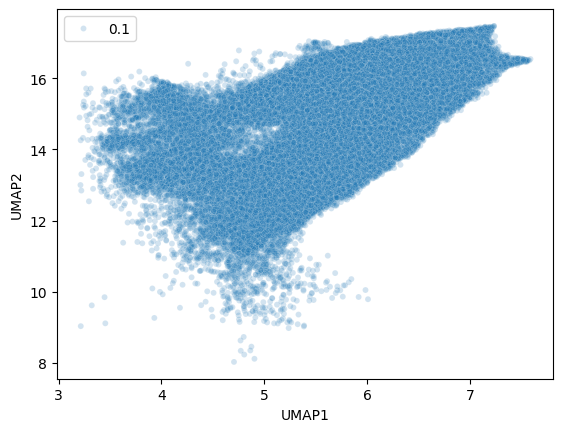

In [64]:
filtered_Lymphoid_adata = ( Lymphoid_adata[(Lymphoid_adata.obs.UMAP1 > 3.2) &
                           (Lymphoid_adata.obs.UMAP2 > 8) ] )
sns.scatterplot(data = filtered_Lymphoid_adata.obs, x = 'UMAP1', y = 'UMAP2', size = 0.1, alpha = 0.2)
print(f"Number of cells filtered out: {Lymphoid_adata.shape[0] - filtered_Lymphoid_adata.shape[0]} cells")

In [65]:
%%time
filtered_Lymphoid_adata.obs['v2_scvi_cell_type'] = "Lymphoid"
filtered_Lymphoid_adata.write(output_dir + "Lymphoid_filtered.h5ad")

<timed exec>:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


CPU times: user 2.02 s, sys: 3.61 s, total: 5.63 s
Wall time: 5.83 s


### Mast

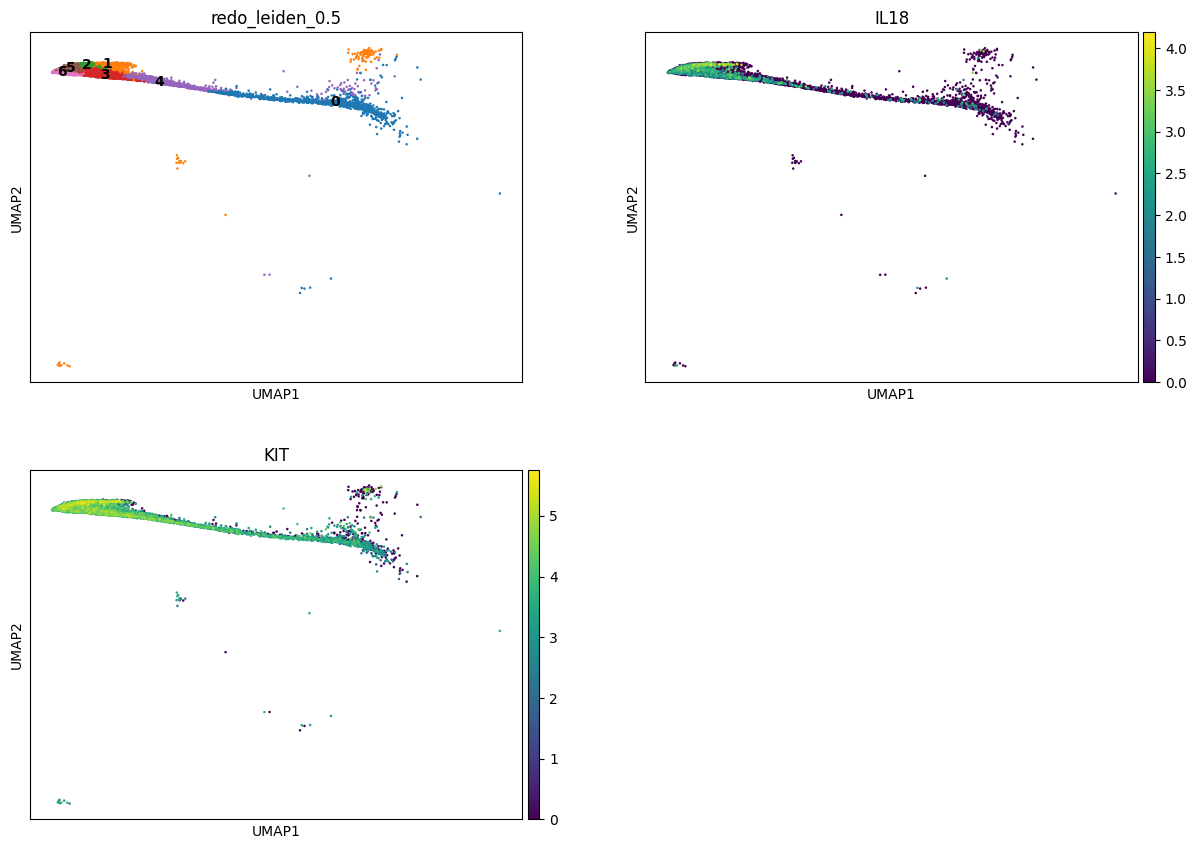

In [35]:
Mast_adata = sc.read_h5ad(input_dir + "Mast.h5ad")
Mast_markers = ["IL18", "KIT"]
sc.pl.umap(Mast_adata, color=[leiden_key] + Mast_markers, legend_loc = "on data", ncols = 2)

In [67]:
#sc.pl.rank_genes_groups_dotplot(Mast_adata, groupby=leiden_key, standard_scale="var", n_genes = 4)

<Axes: xlabel='UMAP1', ylabel='UMAP2'>

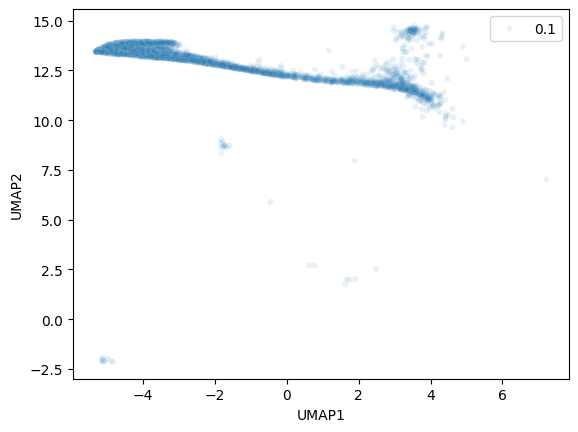

In [66]:
# Add UMAP1 and UMAP2 to the obs DataFrame
Mast_adata = add_umap_coords(Mast_adata)
sns.scatterplot(data = Mast_adata.obs, x = 'UMAP1', y = 'UMAP2', size = 0.1, alpha = 0.1)

Number of cells filtered out:  131 cells


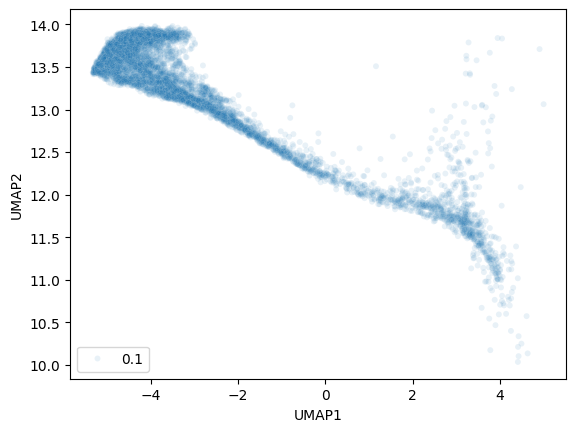

In [69]:
Mast_adata_filtered =  ( Mast_adata[(Mast_adata.obs.UMAP2 > 10) & (Mast_adata.obs.UMAP2 < 14), :] )
sns.scatterplot(data = Mast_adata_filtered.obs, x = 'UMAP1', y = 'UMAP2', size = 0.1, alpha = 0.1)
print(f"Number of cells filtered out:  {Mast_adata.obs.shape[0] - Mast_adata_filtered.obs.shape[0]} cells")

In [70]:
%%time
Mast_adata_filtered.obs["v2_scvi_cell_type"] = "Mast"
Mast_adata_filtered.write(output_dir + "Mast_filtered.h5ad")

<timed exec>:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


CPU times: user 445 ms, sys: 416 ms, total: 860 ms
Wall time: 860 ms


### Myeloid

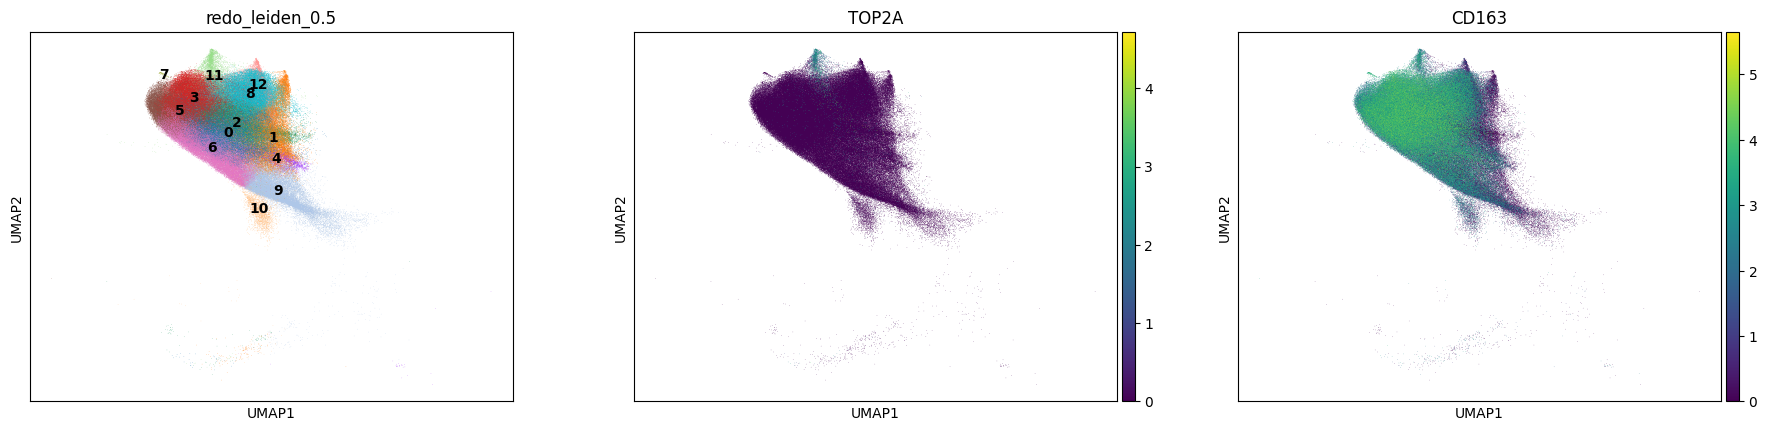

CPU times: user 4.79 s, sys: 7.08 s, total: 11.9 s
Wall time: 11.7 s


In [36]:
%%time
Myeloid_adata = sc.read_h5ad(input_dir + "Myeloid.h5ad")
Myeloid_markers = ["TOP2A", "CD163"]
sc.pl.umap(Myeloid_adata, color=[leiden_key] + Myeloid_markers, legend_loc = "on data")

In [72]:
#sc.get.rank_genes_groups_df(Myeloid_adata, group="6")

<Axes: xlabel='UMAP1', ylabel='UMAP2'>

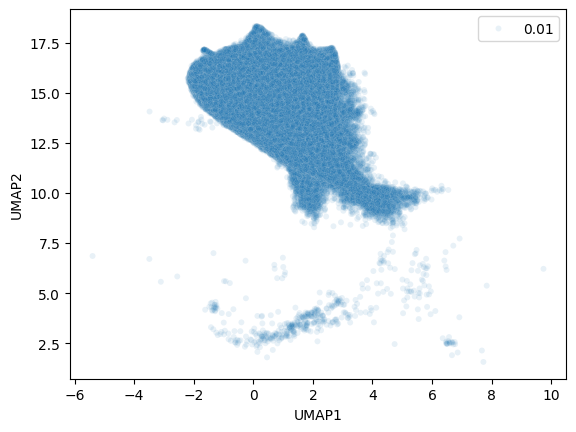

In [73]:
Myeloid_adata = add_umap_coords(Myeloid_adata)
sns.scatterplot(data = Myeloid_adata.obs, x = 'UMAP1', y = 'UMAP2', size = 0.01, alpha = 0.1)

Number of cells filtered out:  485 cells


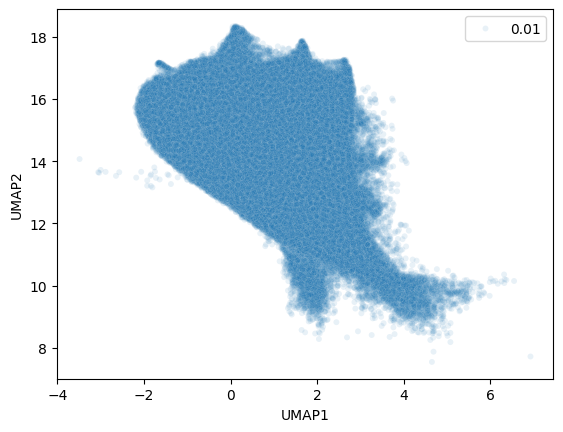

In [74]:
filtered_Myeloid_adata = ( Myeloid_adata[(Myeloid_adata.obs.UMAP2 > 7.5) , :] )
sns.scatterplot(data = filtered_Myeloid_adata.obs, x = 'UMAP1', y = 'UMAP2', size = 0.01, alpha = 0.1)
print(f"Number of cells filtered out:  {Myeloid_adata.shape[0] - filtered_Myeloid_adata.shape[0]} cells")

In [75]:
%%time
filtered_Myeloid_adata.obs["v2_scvi_cell_type"] = "Myeloid"
filtered_Myeloid_adata.write(output_dir + "Myeloid_filtered.h5ad")

<timed exec>:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


CPU times: user 8.21 s, sys: 35.2 s, total: 43.4 s
Wall time: 44.6 s


### Neuronal

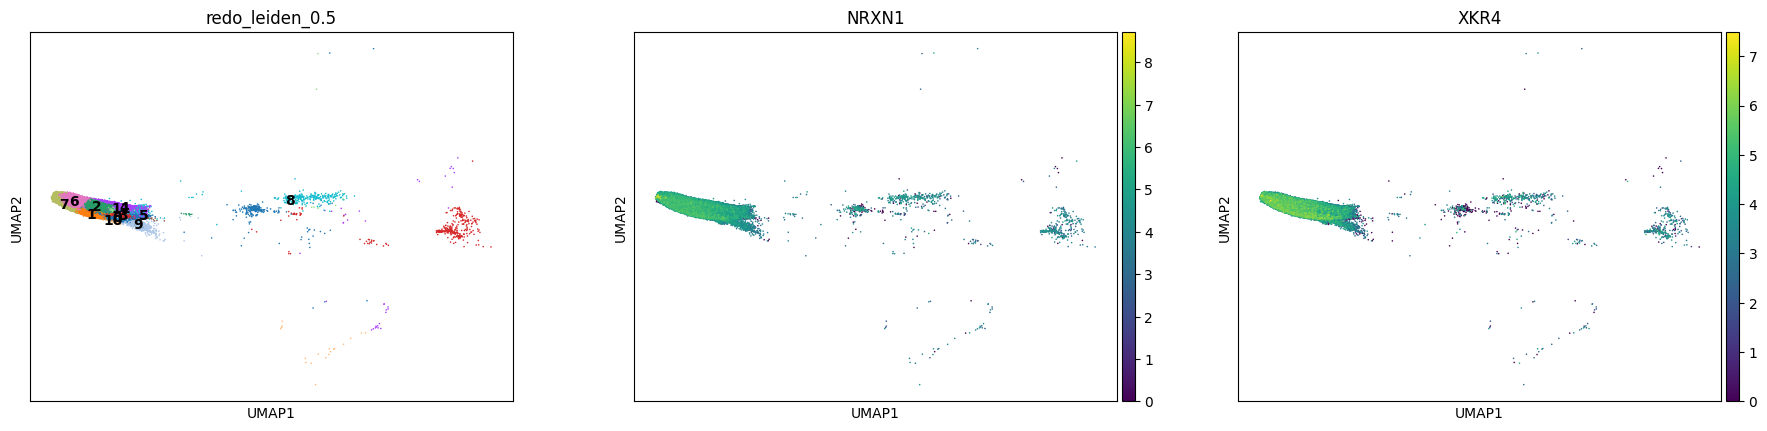

CPU times: user 1.14 s, sys: 946 ms, total: 2.09 s
Wall time: 1.91 s


In [76]:
%%time
Neuronal_adata = sc.read_h5ad(input_dir + "Neuronal.h5ad")
Neuronal_markers = ["NRXN1", "XKR4"]
sc.pl.umap(Neuronal_adata, color=[leiden_key] + Neuronal_markers, legend_loc = "on data")

In [77]:
#sc.pl.rank_genes_groups_dotplot(Neuronal_adata, groupby=leiden_key, standard_scale="var", n_genes = 3)

<Axes: xlabel='UMAP1', ylabel='UMAP2'>

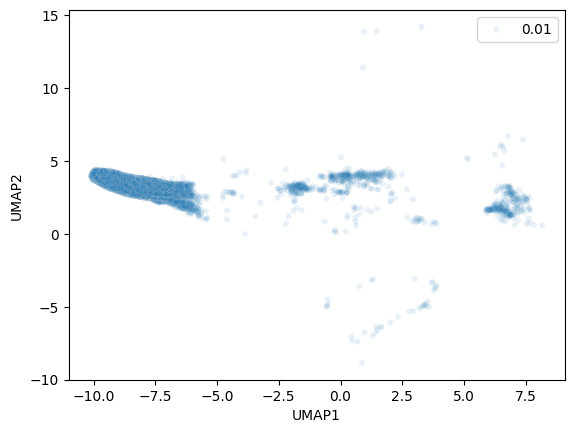

In [78]:
Neuronal_adata = add_umap_coords(Neuronal_adata)
sns.scatterplot(data = Neuronal_adata.obs, x = 'UMAP1', y = 'UMAP2', size = 0.01, alpha = 0.1)

Number of cells filtered out: 906 cells


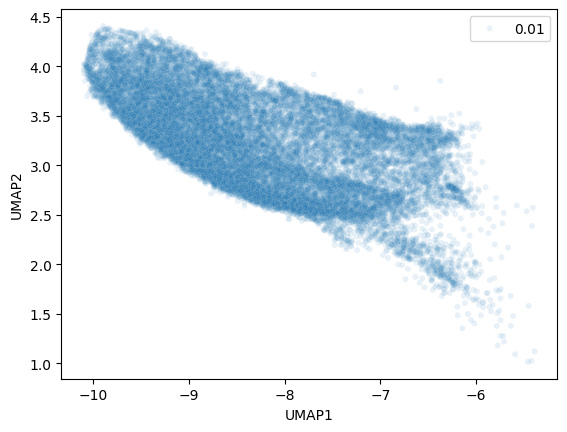

In [79]:
filtered_Neuronal_adata = ( Neuronal_adata[(Neuronal_adata.obs.UMAP1 < -5) , :] )
sns.scatterplot(data = filtered_Neuronal_adata.obs, x = 'UMAP1', y = 'UMAP2', size = 0.01, alpha = 0.1)
print(f"Number of cells filtered out: {Neuronal_adata.shape[0] - filtered_Neuronal_adata.shape[0]} cells")

In [80]:
%%time
filtered_Neuronal_adata.obs["v2_scvi_cell_type"] = "Neuronal"
filtered_Neuronal_adata.write(output_dir + "Neuronal_filtered.h5ad")

<timed exec>:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


CPU times: user 1.01 s, sys: 2.53 s, total: 3.54 s
Wall time: 3.69 s


### Pericyte/vSMC

Will want to divide into Pericyte and vSMC

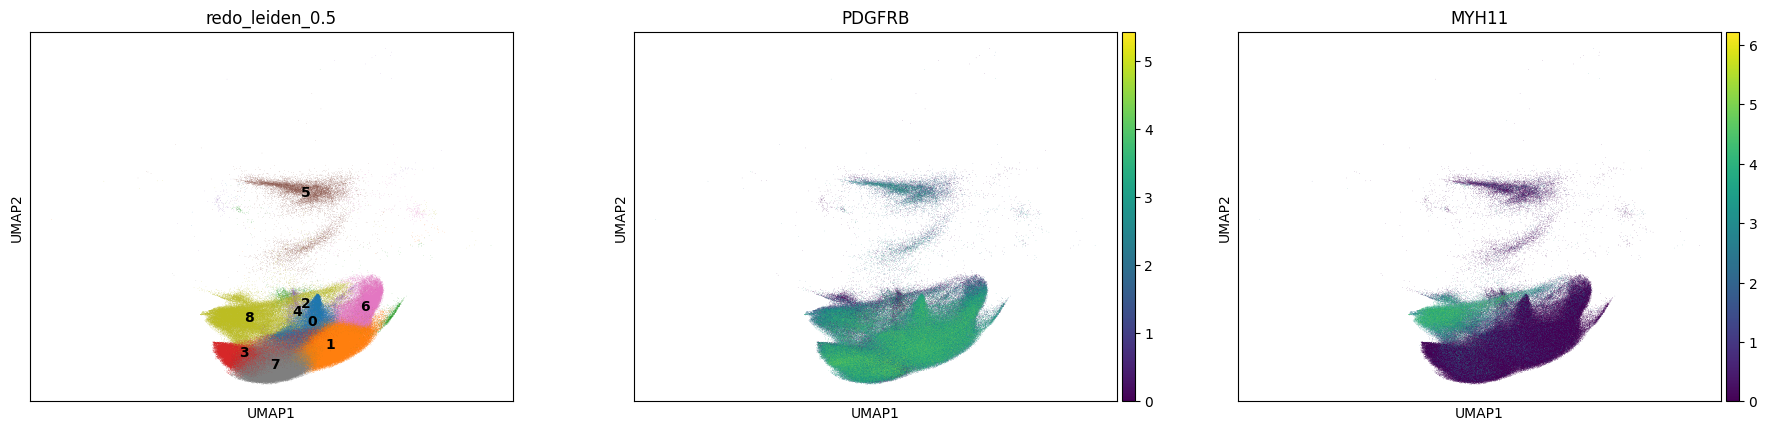

CPU times: user 6.08 s, sys: 8.67 s, total: 14.8 s
Wall time: 14.6 s


In [38]:
%%time
Pericyte_adata = sc.read_h5ad(input_dir + "Pericyte.h5ad")
Pericyte_markers = ["PDGFRB", "MYH11"]
sc.pl.umap(Pericyte_adata, color=[leiden_key] + Pericyte_markers, legend_loc = "on data")

### Leiden cluster 8 has high expression of MYH11 and corresponds to vSMC

In [81]:
#sc.pl.rank_genes_groups_dotplot(Pericyte_adata, groupby=leiden_key, standard_scale="var", n_genes = 3)

<Axes: xlabel='UMAP1', ylabel='UMAP2'>

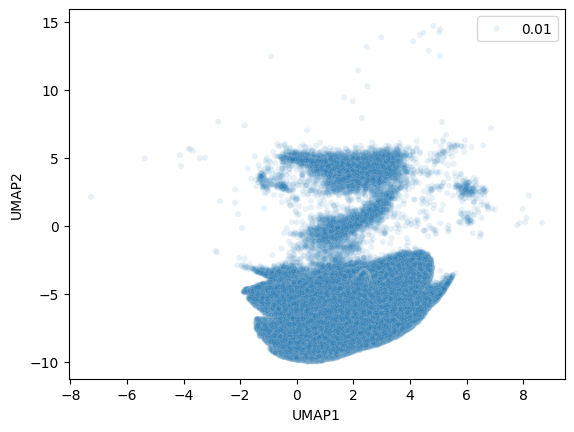

In [82]:
Pericyte_adata = add_umap_coords(Pericyte_adata)
sns.scatterplot(data = Pericyte_adata.obs, x = 'UMAP1', y = 'UMAP2', size = 0.01, alpha = 0.1)

Number of cells filtered out: 73478 cells


<Axes: xlabel='UMAP1', ylabel='UMAP2'>

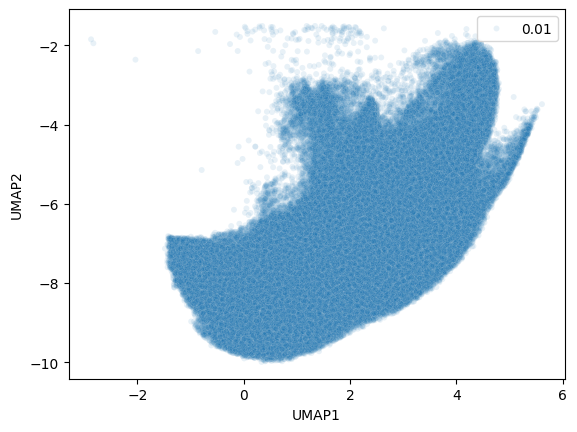

In [86]:
filtered_Pericyte_adata = ( Pericyte_adata[(Pericyte_adata.obs.UMAP2 < -1.5) & 
                           (Pericyte_adata.obs[leiden_key] != "8"), :] )
print(f"Number of cells filtered out: {Pericyte_adata.shape[0] - filtered_Pericyte_adata.shape[0]} cells")
sns.scatterplot(data = filtered_Pericyte_adata.obs, x = 'UMAP1', y = 'UMAP2', size = 0.01, alpha = 0.1)

In [87]:
%%time
filtered_Pericyte_adata.obs["v2_scvi_cell_type"] = "Pericyte"
filtered_Pericyte_adata.write(output_dir + "Pericyte_filtered.h5ad")

<timed exec>:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


CPU times: user 7.52 s, sys: 42.7 s, total: 50.2 s
Wall time: 51.6 s


### vSMC

In [88]:
%%time
vSMC_adata = ( Pericyte_adata[(Pericyte_adata.obs[leiden_key] == "8"), :] ).copy()

CPU times: user 1.42 s, sys: 5.32 s, total: 6.75 s
Wall time: 6.76 s


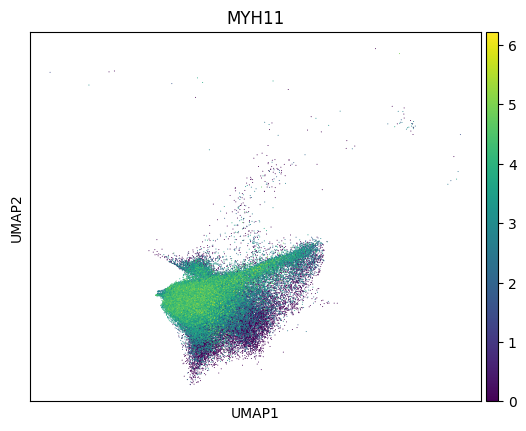

In [89]:
sc.pl.umap(vSMC_adata, color=["MYH11"], legend_loc = "on data")

<Axes: xlabel='UMAP1', ylabel='UMAP2'>

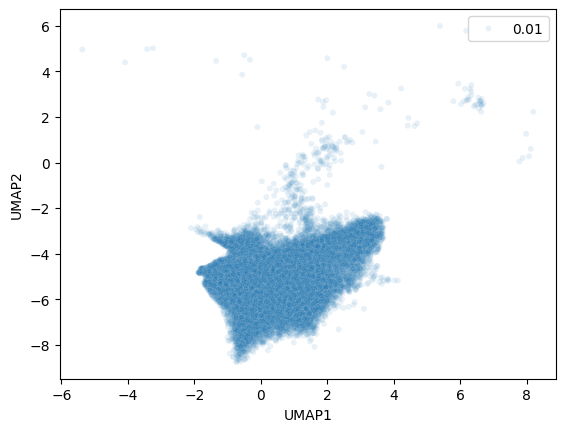

In [90]:
sns.scatterplot(data = vSMC_adata.obs, x = 'UMAP1', y = 'UMAP2', size = 0.01, alpha = 0.1)

Number of cells filtered out: 237 cells


<Axes: xlabel='UMAP1', ylabel='UMAP2'>

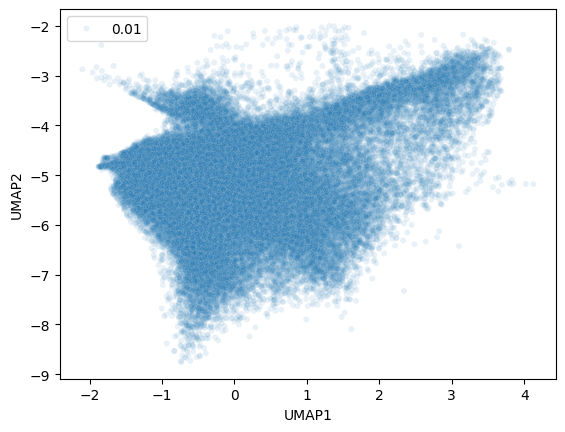

In [91]:
filtered_vSMC_adata = ( vSMC_adata[(vSMC_adata.obs.UMAP2 < -2), :] )
print(f"Number of cells filtered out: {vSMC_adata.shape[0] - filtered_vSMC_adata.shape[0]} cells")
sns.scatterplot(data = filtered_vSMC_adata.obs, x = 'UMAP1', y = 'UMAP2', size = 0.01, alpha = 0.1)

In [92]:
%%time
filtered_vSMC_adata.obs["v2_scvi_cell_type"] = "vSMC"
filtered_vSMC_adata.write(output_dir + "vSMC_filtered.h5ad")

<timed exec>:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


CPU times: user 1.69 s, sys: 8.91 s, total: 10.6 s
Wall time: 10.8 s
